## EPA air quality data analysis 

In [1]:
import pandas as pd
import pdb
import numpy as np
import matplotlib.pyplot as plt
import hvplot.pandas

In [4]:
# read site listing data  - https://aqs.epa.gov/aqsweb/airdata/download_files.html#AQI
sites = pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/aqs_sites.zip')

In [5]:
print(type(sites))
print(sites.shape)
sites.columns

<class 'pandas.core.frame.DataFrame'>
(20940, 28)


Index(['State Code', 'County Code', 'Site Number', 'Latitude', 'Longitude',
       'Datum', 'Elevation', 'Land Use', 'Location Setting',
       'Site Established Date', 'Site Closed Date', 'Met Site State Code',
       'Met Site County Code', 'Met Site Site Number', 'Met Site Type',
       'Met Site Distance', 'Met Site Direction', 'GMT Offset',
       'Owning Agency', 'Local Site Name', 'Address', 'Zip Code', 'State Name',
       'County Name', 'City Name', 'CBSA Name', 'Tribe Name',
       'Extraction Date'],
      dtype='object')

In [6]:
# use bitwise operators
# & for and 
# | for or 
#a= sites.loc[sites['State Name'] == 'New York', ['State Code', 'County Code', 'Site Number', 'Location Setting', 'State Name', 'County Name', 'City Name']]
a= sites.loc[(sites['State Name'] == 'New York') & (sites['County Name'] == 'New York'), ['State Code', 'County Code', 'Site Number', 'Location Setting', 'State Name', 'County Name', 'City Name']]
a

,State Code,County Code,Site Number,Location Setting,State Name,County Name,City Name
12380,36,61,1,URBAN AND CENTER CITY,New York,New York,New York
12381,36,61,2,URBAN AND CENTER CITY,New York,New York,New York
12382,36,61,5,URBAN AND CENTER CITY,New York,New York,New York
12383,36,61,10,URBAN AND CENTER CITY,New York,New York,New York
12384,36,61,13,URBAN AND CENTER CITY,New York,New York,New York
12385,36,61,14,URBAN AND CENTER CITY,New York,New York,New York
12386,36,61,23,URBAN AND CENTER CITY,New York,New York,New York
12387,36,61,24,URBAN AND CENTER CITY,New York,New York,New York
12388,36,61,37,URBAN AND CENTER CITY,New York,New York,New York
12389,36,61,50,URBAN AND CENTER CITY,New York,New York,New York


In [7]:
# use bitwise operators
# & for and 
# | for or 
# a= sites.loc[sites['State Name'] == 'New York', ['State Code', 'County Code', 'Site Number', 'Location Setting', 'State Name', 'County Name', 'City Name']]
a= sites.loc[(sites['State Name'] == 'New York') & (sites['County Name'] == 'Queens'), ['State Code', 'County Code', 'Site Number', 'Location Setting', 'State Name', 'County Name', 'City Name']]
a

,State Code,County Code,Site Number,Location Setting,State Name,County Name,City Name
12549,36,81,4,URBAN AND CENTER CITY,New York,Queens,New York
12550,36,81,8,SUBURBAN,New York,Queens,New York
12551,36,81,15,SUBURBAN,New York,Queens,New York
12552,36,81,16,SUBURBAN,New York,Queens,New York
12553,36,81,20,URBAN AND CENTER CITY,New York,Queens,New York
12554,36,81,26,URBAN AND CENTER CITY,New York,Queens,New York
12555,36,81,29,SUBURBAN,New York,Queens,New York
12556,36,81,30,SUBURBAN,New York,Queens,New York
12557,36,81,40,URBAN AND CENTER CITY,New York,Queens,New York
12558,36,81,41,URBAN AND CENTER CITY,New York,Queens,New York


In [2]:
# Site to download air quality data  
# https://aqs.epa.gov/aqsweb/airdata/download_files.html#AQI
# https://aqs.epa.gov/aqsweb/airdata/daily_88101_2021.zip - daily  PM2.5 

pm25_daily_2020= pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/daily_88101_2020.zip', parse_dates=['Date Local']) 
O3_daily_2020= pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/daily_44201_2020.zip', parse_dates=['Date Local'])
SO2_daily_2020= pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/daily_42401_2020.zip', parse_dates=['Date Local'])
CO_daily_2020= pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/daily_42101_2020.zip', parse_dates=['Date Local'])
NO2_daily_2020= pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/daily_42602_2020.zip', parse_dates=['Date Local'])

C:\Users\Wenge\AppData\Local\Temp\ipykernel_27732\777950827.py:6: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  O3_daily_2020= pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/daily_44201_2020.zip', parse_dates=['Date Local'])
C:\Users\Wenge\AppData\Local\Temp\ipykernel_27732\777950827.py:7: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  SO2_daily_2020= pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/daily_42401_2020.zip', parse_dates=['Date Local'])
C:\Users\Wenge\AppData\Local\Temp\ipykernel_27732\777950827.py:8: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  CO_daily_2020= pd.read_csv('https://aqs.epa.gov/aqsweb/airdata/daily_42101_2020.zip', parse_dates=['Date Local'])
C:\Users\Wenge\AppData\Local\Temp\ipykernel_27732\777950827.py:9: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set l

In [13]:
pm25_daily_2020.columns

Index(['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC',
       'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration',
       'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type',
       'Observation Count', 'Observation Percent', 'Arithmetic Mean',
       '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name',
       'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name',
       'CBSA Name', 'Date of Last Change'],
      dtype='object')

In [11]:
O3_daily_2020.shape

(391845, 29)

In [122]:
SO2_daily_2020.shape

(324817, 29)

In [123]:
CO_daily_2020.shape

(178789, 29)

In [124]:
NO2_daily_2020.shape

(157726, 29)

In [14]:
pm25_daily_2020.head(20)

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,AQI,Method Code,Method Name,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
0,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,56.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-09-05
1,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,18.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-09-05
2,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,18.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-09-05
3,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,51.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-09-05
4,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,38.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-09-05
5,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,21.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-09-05
6,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,13.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-09-05
7,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,51.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-09-05
8,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,23.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-09-05
9,1,3,10,88101,1,30.497478,-87.880258,NAD83,PM2.5 - Local Conditions,24 HOUR,...,27.0,145,R & P Model 2025 PM-2.5 Sequential Air Sampler...,"FAIRHOPE, Alabama","FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE...",Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",2024-09-05


In [15]:
pm25_daily_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704090 entries, 0 to 704089
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   State Code           704090 non-null  int64         
 1   County Code          704090 non-null  int64         
 2   Site Num             704090 non-null  int64         
 3   Parameter Code       704090 non-null  int64         
 4   POC                  704090 non-null  int64         
 5   Latitude             704090 non-null  float64       
 6   Longitude            704090 non-null  float64       
 7   Datum                704090 non-null  object        
 8   Parameter Name       704090 non-null  object        
 9   Sample Duration      704090 non-null  object        
 10  Pollutant Standard   385671 non-null  object        
 11  Date Local           704090 non-null  datetime64[ns]
 12  Units of Measure     704090 non-null  object        
 13  Event Type    

In [16]:
pm25_daily_2020.columns
pm25_daily_2020.index
pm25_daily_2020.values

array([[1, 3, 10, ..., 'Fairhope', 'Daphne-Fairhope-Foley, AL',
        '2024-09-05'],
       [1, 3, 10, ..., 'Fairhope', 'Daphne-Fairhope-Foley, AL',
        '2024-09-05'],
       [1, 3, 10, ..., 'Fairhope', 'Daphne-Fairhope-Foley, AL',
        '2024-09-05'],
       ...,
       [80, 2, 14, ..., 'Mexicali', nan, '2024-08-07'],
       [80, 2, 14, ..., 'Mexicali', nan, '2024-08-07'],
       [80, 2, 14, ..., 'Mexicali', nan, '2024-08-07']],
      shape=(704090, 29), dtype=object)

In [3]:
pm25_NY_2020 = pm25_daily_2020.loc[(pm25_daily_2020['County Name']== 'New York'), ['Site Num', 'Local Site Name', 'Date Local', 'AQI']]
pm25_NY_2020

,Site Num,Local Site Name,Date Local,AQI
422729,79,IS 45,2020-01-01,13.0
422730,79,IS 45,2020-01-04,56.0
422731,79,IS 45,2020-01-07,46.0
422732,79,IS 45,2020-01-10,34.0
422733,79,IS 45,2020-01-13,43.0
...,...,...,...,...
422855,134,DIVISION STREET,2020-02-24,65.0
422856,134,DIVISION STREET,2020-02-27,44.0
422857,134,DIVISION STREET,2020-03-01,36.0
422858,134,DIVISION STREET,2020-03-04,23.0


<Axes: xlabel='Date Local'>

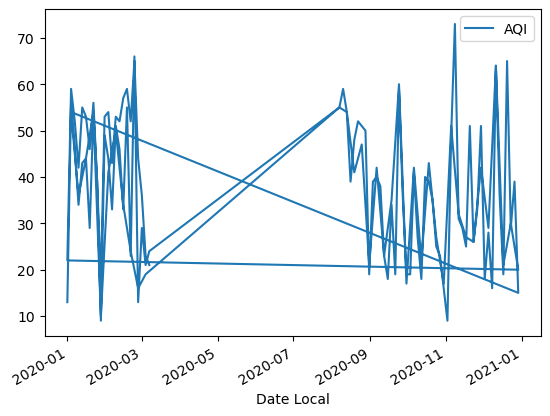

In [8]:
pm25_NY_2020.plot(x='Date Local', y='AQI')

In [12]:
# extract site numbers, date and AQI 
pm25_NY_79 = pm25_daily_2020.loc[(pm25_daily_2020['County Name']== 'New York') & (pm25_daily_2020['Site Num']== 79) , ['Site Num', 'Date Local', 'AQI']]
pm25_NY_134 = pm25_daily_2020.loc[(pm25_daily_2020['County Name']== 'New York') & (pm25_daily_2020['Site Num']== 134), ['Site Num', 'Date Local', 'AQI']]


In [59]:
pm25_NY_79.shape

(108, 3)

In [60]:
pm25_NY_124.shape

(23, 3)

In [13]:
pm25_NY_79.sort_values('Date Local')

,Site Num,Date Local,AQI
422729,79,2020-01-01,13.0
422730,79,2020-01-04,56.0
422801,79,2020-01-04,54.0
422731,79,2020-01-07,46.0
422732,79,2020-01-10,34.0
...,...,...,...
422835,79,2020-12-23,30.0
422798,79,2020-12-23,29.0
422799,79,2020-12-26,39.0
422800,79,2020-12-29,15.0


<Axes: xlabel='Date Local'>

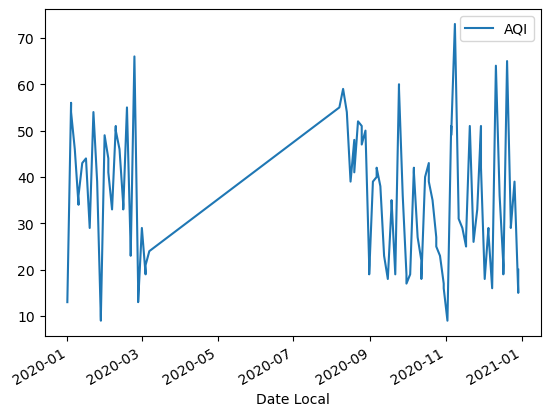

In [14]:
pm25_NY_79.sort_values('Date Local').plot(x='Date Local', y='AQI')

In [29]:
pm25_NY_134

,Site Num,Date Local,AQI
422837,134,2020-01-01,22.0
422838,134,2020-01-04,59.0
422839,134,2020-01-07,52.0
422840,134,2020-01-10,42.0
422841,134,2020-01-13,55.0
422842,134,2020-01-16,53.0
422843,134,2020-01-19,46.0
422844,134,2020-01-22,56.0
422845,134,2020-01-25,39.0
422846,134,2020-01-28,18.0


<Axes: xlabel='Date Local'>

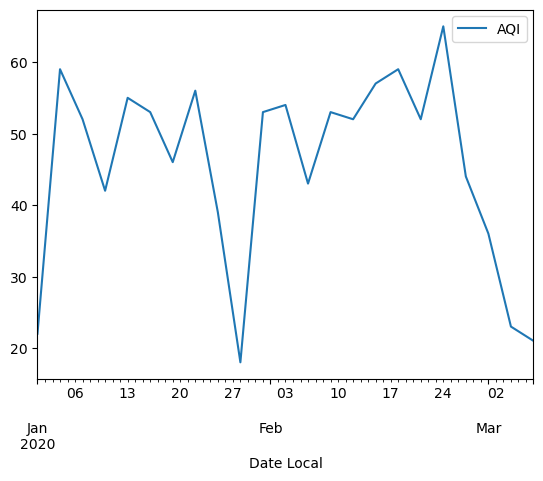

In [30]:
pm25_NY_134.plot(x='Date Local', y='AQI')

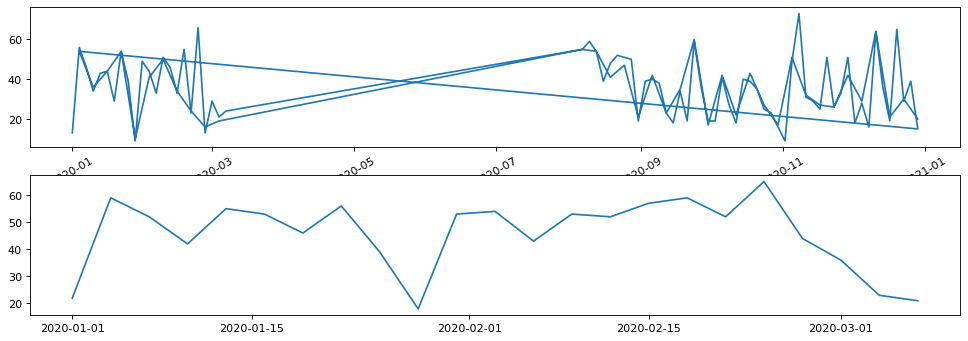

In [18]:
# plot the time series of AQI 
plt.figure(figsize=(15,5), dpi=80)
plt.subplot(2, 1, 1)
plt.plot(pm25_NY_79['Date Local'], pm25_NY_79['AQI'])
#plt.plot(pm25_NY['Date Local'], pm25_NY['AQI'],label='No mask')
#plt.plot(pm25_NY['Date Local'], pm25_NY['AQI'],label='Masked values')
plt.xticks(rotation = 30, horizontalalignment = 'center')
plt.subplot(2,1,2)
plt.plot(pm25_NY_134['Date Local'], pm25_NY_134['AQI'])

In [19]:
# hvplot 
pm25_NY_79.hvplot(x='Date Local', y='AQI')

:Curve   [Date Local]   (AQI)

<Axes: xlabel='Date Local'>

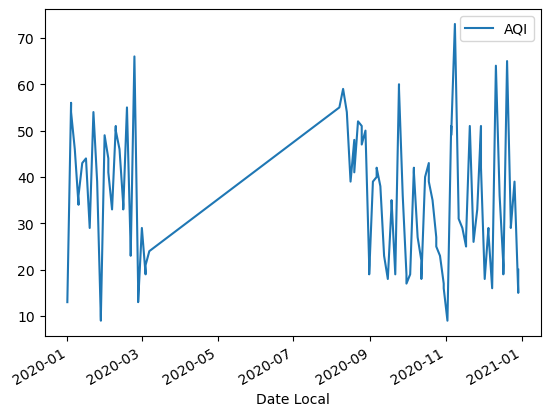

In [23]:
pm25_NY_79.sort_values('Date Local').plot(x='Date Local', y='AQI')